# Preliminary EDA + Cleaning + Pre Processing

## Import thư viện
Nạp các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None) 
pd.set_option("display.max_rows", 100)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to C:\Users\ASPIRE
[nltk_data]     7\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ASPIRE
[nltk_data]     7\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Load Dataset
Đọc file dữ liệu

In [2]:
df = pd.read_csv("../Dataset/raw/merged_amazon_dataset.csv")

print(df.shape)

df.head()

(227695, 44)


,about_item,asin,availability,best_sellers_rank,brand_name,list_price,manufacturer,model_number,price_value,product_description,rating_count,rating_distribution_1star,rating_distribution_2star,rating_distribution_3star,rating_distribution_4star,rating_distribution_5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,rank_1,productasin,productvariant,rating,reviewid,reviewmetadata,reviewposition,reviewtext,reviewtitle,reviewurl,verifiedpurchase,videos_0,cleaned_review_text,sentiment_score,_source,parent_asin,target,verified_purchases,text,helpful_vote,user_id,timestamp
0,Premium Comfort: Crafted from a high-quality c...,B0B59BJG6Y,In Stock,"#56,836 in Clothing, Shoes & Jewelry (See Top ...",MLYENX Store,List Price: $53.99,NaN,NaN,39.9926,NaN,"1,654 ratings",2%,1%,7%,15%,75%,4.6 out of 5 stars,50+ bought,03-10-2025 21:42,Greenfive,https://www.amazon.com/gp/help/seller/at-a-gla...,4/5 Pack Mens Polo Shirts Short Sleeve Quick D...,85.0,B0DLGB4RYH,Color: BlackSize: X-Large,5.0,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",1.0,‚úçÔ∏è The COOFANDY Men's Polo Shirt is a fant...,Stylish and Lightweight COOFANDY Polo Shirt,https://www.amazon.com/review/R2AUQFPJY5ERCZ,False,NaN,coofandy men polo shirt fantastic blend style ...,0.292024,ecommerce,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Material: Men's polo shirt is made of soft pol...,B0DLGB4RYH,In Stock,"#50,261 in Clothing, Shoes & Jewelry (See Top ...",COOFANDY Store,Typical price: $24.99,NaN,NaN,19.9920,NaN,20 ratings,0%,6%,11%,17%,66%,4.4 out of 5 stars,NaN,03-10-2025 21:42,COOFANDY,https://www.amazon.com/gp/help/seller/at-a-gla...,COOFANDY Men's Polo Shirts Short Sleeve Moistu...,199.0,B0DRXF62JH,Color: Bblack Grey NavySize: 3X-Large,5.0,R1YNLJ0QFLB1VT,"Reviewed in the United States on March 7, 2025",1.0,I love these. They look good. They fit well. T...,New favorite shirts,https://www.amazon.com/review/R1YNLJ0QFLB1VT,False,NaN,love look good fit well comfortable breathable...,0.560000,ecommerce,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"PERFORMANCE:These men polo shirts are soft,lig...",B0DRXF62JH,In Stock,"#69,641 in Clothing, Shoes & Jewelry (See Top ...",ZITY Store,List Price: $59.99,NaN,NaN,29.9950,NaN,5 ratings,0%,0%,0%,37%,63%,4.6 out of 5 stars,NaN,03-10-2025 21:42,ZITY®,https://www.amazon.com/gp/help/seller/at-a-gla...,ZITY 3 Pack Men Polo Shirts Short Sleeve with ...,111.0,B0DRXF62JH,Color: Grey Navy DuckblueSize: Medium,4.0,R11LIYW9RMDK9R,"Reviewed in the United States on February 27, ...",2.0,My expectations were low -- how good could shi...,Incredibly Good Deal,https://www.amazon.com/review/R11LIYW9RMDK9R,False,NaN,expectation low good could shirt sell one mist...,0.192321,ecommerce,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,【Material】: These golf shirts for men are made...,B0DK5FZ325,In Stock,"#194,649 in Clothing, Shoes & Jewelry (See Top...",Rouen Store,NaN,NaN,NaN,32.9500,NaN,22 ratings,0%,0%,0%,20%,80%,4.8 out of 5 stars,NaN,03-10-2025 21:43,MICHEL ROUEN,https://www.amazon.com/gp/help/seller/at-a-gla...,Rouen Mens Golf Shirt Moisture Wicking Dry Fit...,266.0,B0DRXF62JH,Color: Black Duckblue WineredSize: X-Large,5.0,R3K9X391DJNTPZ,"Reviewed in the United States on February 26, ...",3.0,This 3-pack of multi-color shirts is really a ...,Higher quality & breathable 3-pack shirt set t...,https://www.amazon.com/review/R3K9X391DJNTPZ,False,NaN,pack multicolor shirt really brainer wear type...,0.307949,ecommerce,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MOISTURE WICKING: The fabric of the summer gol...,B0BGXTC1FR,In Stock,"#3,664 in Clothing, Shoes & Jewelry (See Top 1...",V VALANCH Store,List Price: $38.99,NaN,NaN,26.9931,NaN,"2,175 ratings",5%,2%,7%,17%,69%,4.4 out of 5 stars,NaN,03-10-2025 21:43,Zhengdaqian,https://www.amazon.com/gp/help/seller/at-a-gla...,V VALANCH Mens Polo Shirts Short Sleeve Moistu...,11.0,B0DRXF62JH,Color: Bblack Grey NavySize: X-Large,5.0,RP17IW9ZKENDZ,"Reviewed in the United States on February 20, ...",4.0,With these three polo shirts I was very s

## Khai báo nhóm thuộc tính
Chia các cột theo từng nhóm để dễ xử lý

In [3]:
numeric_cols = [
    "price_value",
    "list_price",
    "rating_stars",
    "sentiment_score",
    "rating_count",
    "helpful_vote"
]

categorical_cols = [
    "availability",
    "verified_purchase",
    "brand_name",
    "manufacturer",
    "seller_name"
]

text_cols = [
    "reviewText",
    "text",
    "about_item",
    "product_description"
]

## Tổng quan dữ liệu
Kích thước dataset, kiểu dữ liệu, số lượng giá trị không NULL và thống kê mô tả cơ bản 

In [4]:
print("Shape:")
print(df.shape)

print("Info:")
df.info()

print("Describe Numeric:")
display(df.describe())

print("Describe Object:")
display(df.describe(include="object"))

Shape:
(227695, 44)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227695 entries, 0 to 227694
Data columns (total 44 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   about_item                 728 non-null     object 
 1   asin                       221867 non-null  object 
 2   availability               715 non-null     object 
 3   best_sellers_rank          558 non-null     object 
 4   brand_name                 728 non-null     object 
 5   list_price                 401 non-null     object 
 6   manufacturer               266 non-null     object 
 7   model_number               199 non-null     object 
 8   price_value                707 non-null     float64
 9   product_description        271 non-null     object 
 10  rating_count               719 non-null     object 
 11  rating_distribution_1star  728 non-null     object 
 12  rating_distribution_2star  728 non-null     object 
 13  rat

,price_value,rank_1,rating,reviewposition,sentiment_score,target,helpful_vote,timestamp
count,707.000000,540.000000,227459.000000,6327.000000,6327.000000,221139.000000,221139.000000,2.211390e+05
mean,35.323948,174.622222,3.131294,5.374743,0.307545,0.061468,0.953355,1.549846e+12
std,26.422336,240.115097,1.397192,2.889921,0.218020,0.892704,5.510239,7.008351e+10
min,5.457300,1.000000,1.000000,1.000000,-1.000000,-1.000000,0.000000,1.053127e+12
25%,19.990000,18.000000,2.000000,3.000000,0.168568,-1.000000,0.000000,1.500502e+12
50%,28.950000,56.500000,3.000000,5.000000,0.300000,0.000000,0.000000,1.552612e+12
75%,41.771600,220.250000,4.000000,8.000000,0.450000,1.000000,1.000000,1.604837e+12
max,249.990000,994.000000,5.000000,10.000000,1.000000,1.000000,954.000000,1.693507e+12


Describe Object:


,about_item,asin,availability,best_sellers_rank,brand_name,list_price,manufacturer,model_number,product_description,rating_count,rating_distribution_1star,rating_distribution_2star,rating_distribution_3star,rating_distribution_4star,rating_distribution_5star,rating_stars,recent_purchases,scrape_time,seller_name,seller_page_url,title,productasin,productvariant,reviewid,reviewmetadata,reviewtext,reviewtitle,reviewurl,verifiedpurchase,videos_0,cleaned_review_text,_source,parent_asin,verified_purchases,text,user_id
count,728,221867,715,558,728,401,266,199,271,719,728,728,728,728,728,719,569,728,707,426,221867,6327,5836,6327,6296,6289,6313,6327,6327,34,6288,227695,221139,221139,221139,221139
unique,697,162978,11,539,285,205,131,191,238,645,34,19,24,33,63,24,19,120,267,426,154858,700,4923,6327,774,6232,5162,6327,2,34,6182,2,154288,2,219656,207548
top,"Textured fabric that's soft, light & breathabl...",B000GAWSDG,In Stock,"#67 in Clothing, Shoes & Jewelry (See Top 100 ...",Hanes Store,List Price: $39.99,Amazon Essentials,1290140,We listen to customer feedback and fine-tune e...,5 ratings,3%,2%,6%,15%,75%,4.5 out of 5 stars,100+ bought,03-10-2025 22:38,Amazon.com,https://www.amazon.com/gp/help/seller/at-a-gla...,Five Stars,B074KL8RVS,Size: MediumColor: Black,R2AUQFPJY5ERCZ,"Reviewed in the United States on March 6, 2025",Excelente,Comfortable,https://www.amazon.com/review/R2AUQFPJY5ERCZ,True,https://m.media-amazon.com/images/I/D1MrqEYXaf...,good,800k_fashion,B09KHSM7BB,True,Nice dress,AG73BVBKUOH22USSFJA5ZWL7AKXA
freq,3,218,640,3,35,10,21,3,8,4,123,194,107,89,44,131,108,18,278,1,3453,19,31,1,154,8,64,1,6167,1,13,221139,652,200251,51,58


## Báo cáo kiểu dữ liệu
Tạo bảng tổng hợp kiểu dữ liệu và số lượng Missing Values của từng cột

In [5]:
dtype_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes,
    "Missing Count": df.isna().sum()
})

dtype_report

,Column,Data Type,Missing Count
about_item,about_item,object,226967
asin,asin,object,5828
availability,availability,object,226980
best_sellers_rank,best_sellers_rank,object,227137
brand_name,brand_name,object,226967
list_price,list_price,object,227294
manufacturer,manufacturer,object,227429
model_number,model_number,object,227496
price_value,price_value,float64,226988
product_description,product_description,object,227424


## Kiểm tra Missing Values 
Tính số lượng và tỷ lệ phần trăm Missing Value của từng thuộc tính

In [6]:
missing_report = pd.DataFrame({
    "Attribute": df.columns,
    "Missing Count": df.isna().sum(),
    "Missing %": round(df.isna().mean() * 100, 2)
})

missing_report = missing_report.sort_values(
    by="Missing %",
    ascending=False
)

missing_report

,Attribute,Missing Count,Missing %
videos_0,videos_0,227661,99.99
model_number,model_number,227496,99.91
manufacturer,manufacturer,227429,99.88
product_description,product_description,227424,99.88
list_price,list_price,227294,99.82
seller_page_url,seller_page_url,227269,99.81
rank_1,rank_1,227155,99.76
best_sellers_rank,best_sellers_rank,227137,99.75
recent_purchases,recent_purchases,227126,99.75
availability,availability,226980,99.69


## Biểu đồ Missing Value
Trực quan hóa 20 cột có tỷ lệ missing cao nhất

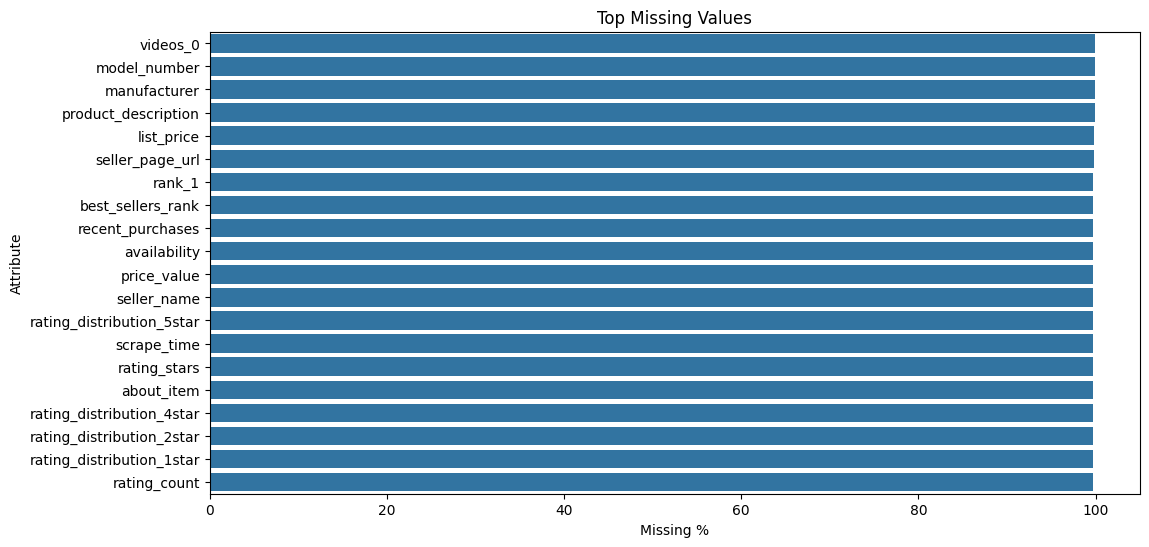

In [7]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=missing_report.head(20),
    x="Missing %",
    y="Attribute"
)

plt.title("Top Missing Values")
plt.show()

## Kiểm tra Duplicate
Kiểm tra trùng dòng, trùng reviewid, và trùng asin.

In [8]:
duplicate_rows = df.duplicated().sum()

duplicate_reviewid = (
    df["reviewid"].duplicated().sum()
    if "reviewid" in df.columns
    else 0
)

duplicate_asin = (
    df["asin"].duplicated().sum()
    if "asin" in df.columns
    else 0
)

duplicate_report = pd.DataFrame({
    "Type": [
        "Duplicate Rows",
        "Duplicate ReviewID",
        "Duplicate ASIN"
    ],
    "Count": [
        duplicate_rows,
        duplicate_reviewid,
        duplicate_asin
    ]
})

duplicate_report

,Type,Count
0,Duplicate Rows,0
1,Duplicate ReviewID,221367
2,Duplicate ASIN,64716


## Thống kê mô tả biến số
Tính trung bình, trung vị, nhỏ nhất, lớn nhất và độ lệch chuẩn cho các biến số

In [9]:
available_numeric_cols = [
    col for col in numeric_cols
    if col in df.columns
]

summary_stats = (
    df.select_dtypes(include='number')  # Chỉ lấy các cột là số (int, float)
    .agg(["mean", "median", "min", "max", "std"])
)

summary_stats

,price_value,rank_1,rating,reviewposition,sentiment_score,target,helpful_vote,timestamp
mean,35.323948,174.622222,3.131294,5.374743,0.307545,0.061468,0.953355,1.549846e+12
median,28.950000,56.500000,3.000000,5.000000,0.300000,0.000000,0.000000,1.552612e+12
min,5.457300,1.000000,1.000000,1.000000,-1.000000,-1.000000,0.000000,1.053127e+12
max,249.990000,994.000000,5.000000,10.000000,1.000000,1.000000,954.000000,1.693507e+12
std,26.422336,240.115097,1.397192,2.889921,0.218020,0.892704,5.510239,7.008351e+10


## Khảo sát độ dài văn bản
Đo độ dài trung bình, lớn nhất và nhỏ nhất của các cột văn bản

In [10]:
text_report = []

for col in [
    "reviewText",
    "cleaned_review_text",
    "about_item",
    "product_description"
]:

    if col in df.columns:

        lengths = (
            df[col]
            .fillna("")
            .astype(str)
            .str.len()
        )

        text_report.append({
            "Column": col,
            "Average Length": lengths.mean(),
            "Max Length": lengths.max(),
            "Min Length": lengths.min()
        })

text_report = pd.DataFrame(text_report)

text_report

,Column,Average Length,Max Length,Min Length
0,cleaned_review_text,5.744799,9498,0
1,about_item,2.194725,2144,0
2,product_description,0.403342,2025,0


## Đề xuất các cột cần loại bỏ
Tìm các cột có khả năng là URL, ảnh, metadata hoặc ID không cần thiết

In [11]:
url_cols = [
    col for col in df.columns
    if "url" in col.lower()
]

metadata_cols = [
    col for col in df.columns
    if any(
        keyword in col.lower()
        for keyword in [
            "source",
            "crawl",
            "html",
            "image"
        ]
    )
]

technical_id_cols = [
    col for col in df.columns
    if (
        "id" in col.lower()
        and col.lower() not in [
            "asin",
            "parent_asin",
            "reviewid"
        ]
    )
]

drop_cols = list(
    set(
        url_cols +
        metadata_cols +
        technical_id_cols
    )
)

pd.DataFrame({
    "Suggested Drop Columns": drop_cols
})

,Suggested Drop Columns
0,videos_0
1,seller_page_url
2,_source
3,reviewurl
4,user_id


## Tạo bản sao để làm sạch 
Tạo df_clean để làm sạch dữ liệu mà không làm thay đổi dataset gốc

In [12]:
df_clean = df.copy()

## Xử lý Missing Value cho biến số
Chuyển các biến số về dạng numeric. Sau đó, missing value được thay bằng median

In [13]:
for col in numeric_cols:

    if col in df_clean.columns:

        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors="coerce"
        )

        df_clean[col] = df_clean[col].fillna(
            df_clean[col].median()
        )

## Xử lý Missing Value cho biến phân loại
Thay missing value trong biến phân loại bằng "unknown"

In [14]:
for col in categorical_cols:

    if col in df_clean.columns:

        df_clean[col] = df_clean[col].fillna("unknown")

## Xử lý missing values cho biến văn bản
Thay missing value trong biến văn bản bằng chuỗi rỗng

In [15]:
for col in text_cols:

    if col in df_clean.columns:

        df_clean[col] = df_clean[col].fillna("")

## Xử lý Duplicate
Loại bỏ các dòng trùng hoàn toàn. Nếu có reviewid, tiếp tục loại bỏ các review bị trùng ID

In [16]:
df_clean = df_clean.drop_duplicates()

if "reviewid" in df_clean.columns:

    df_clean = df_clean.drop_duplicates(
        subset=["reviewid"],
        keep="first"
    )

## Chuẩn hóa kiểu dữ liệu số
Đảm bảo các biến số nằm ở dạng numeric

In [17]:
for col in numeric_cols:

    if col in df_clean.columns:

        df_clean[col] = pd.to_numeric(
            df_clean[col],
            errors="coerce"
        )

## Phát hiện Outlier bằng IQR
Chỉ phát hiện outlier, không loại bỏ

In [18]:
outlier_report = []

for col in numeric_cols:

    if col in df_clean.columns:

        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)

        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = (
            (df_clean[col] < lower) |
            (df_clean[col] > upper)
        ).sum()

        outlier_report.append({
            "Column": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Outlier Count": outliers
        })

outlier_report = pd.DataFrame(outlier_report)

outlier_report

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,price_value,28.950000,28.95,0.000000,28.950000,28.950000,491
1,list_price,NaN,NaN,NaN,NaN,NaN,0
2,rating_stars,NaN,NaN,NaN,NaN,NaN,0
3,sentiment_score,0.168659,0.45,0.281341,-0.253353,0.872012,89
4,rating_count,NaN,NaN,NaN,NaN,NaN,0
5,helpful_vote,0.000000,0.00,0.000000,0.000000,0.000000,0


## Chuẩn hóa kiểu dữ liệu phân loại
Chuẩn hóa chữ thường, xóa khoảng trắng thừa và thống nhất giá trị rỗng

In [19]:
for col in categorical_cols:

    if col in df_clean.columns:

        df_clean[col] = (
            df_clean[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({
                "nan": "unknown",
                "none": "unknown",
                "null": "unknown",
                "": "unknown"
            })
        )

## Hàm làm sạch văn bản
Định nghĩa hàm xử lý văn bản cho dữ liệu review và mô tả sản phẩm

In [20]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"<.*?>",
        " ",
        text
    )

    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    text = re.sub(
        r"[^a-zA-Z\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

## Pre-processing
Gộp lại các nguồn văn bản và làm sạch

In [21]:
df_clean["combined_text"] = ""

for col in text_cols:

    if col in df_clean.columns:

        df_clean["combined_text"] += (
            " " + df_clean[col].fillna("").astype(str)
        )

df_clean["cleaned_review_text"] = (
    df_clean["combined_text"]
    .apply(clean_text)
)

## Kiểm tra kết quả làm sạch văn bản
So sánh văn bản gốc và văn bản sau khi làm sạch 

In [22]:
df_clean[
    [
        "combined_text",
        "cleaned_review_text"
    ]
].head()

,combined_text,cleaned_review_text
0,Premium Comfort: Crafted from a high-quality...,premium comfort crafted high quality cotton bl...
1,Material: Men's polo shirt is made of soft p...,material men polo shirt made soft polyester fa...
2,"PERFORMANCE:These men polo shirts are soft,l...",performance men polo shirt soft lightweight mo...
3,【Material】: These golf shirts for men are ma...,material golf shirt men made quality polyester...
4,MOISTURE WICKING: The fabric of the summer g...,moisture wicking fabric summer golf shirt abso...


## Báo cáo sau làm sạch
Kiểm tra lại kích thước dataset, missing value và duplicate sau khi xử lý

In [23]:
print("Dataset Before Cleaning:")
print(df.shape)

print("Dataset After Cleaning:")
print(df_clean.shape)

print("Missing Values After Cleaning:")
display(df_clean.isna().sum())

print("Duplicate Rows After Cleaning:")
print(df_clean.duplicated().sum())

Dataset Before Cleaning:
(227695, 44)
Dataset After Cleaning:
(6328, 45)
Missing Values After Cleaning:


about_item                      0
asin                         5828
availability                    0
best_sellers_rank            5862
brand_name                      0
list_price                   6328
manufacturer                    0
model_number                 6160
price_value                     0
product_description             0
rating_count                 6328
rating_distribution_1star    5828
rating_distribution_2star    5828
rating_distribution_3star    5828
rating_distribution_4star    5828
rating_distribution_5star    5828
rating_stars                 6328
recent_purchases             5926
scrape_time                  5828
seller_name                     0
seller_page_url              6051
title                        5828
rank_1                       5876
productasin                     1
productvariant                492
rating                          8
reviewid                        1
reviewmetadata                 32
reviewposition                  1
reviewtext    

Duplicate Rows After Cleaning:
0


## Lưu dataset 

In [24]:
df_final = df_clean.copy()

print("Final Dataset Shape:")
print(df_final.shape)


# Lưu file
df_final.to_csv(
    "../Dataset/processed/cleaned_amazon_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved: ../Dataset/processed/cleaned_amazon_dataset.csv")

Final Dataset Shape:
(6328, 45)
Saved: ../Dataset/processed/cleaned_amazon_dataset.csv
